<a href="https://colab.research.google.com/github/andreafalcon05-collab/Modelos_estocasticos/blob/main/T1_Ejemplos_de_modelos_estocasticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 - Ejemplos de Procesos Estocásticos

## 1- Del rendimiento de los Cetes a 28 días y genere una curva de plazos para los valores

In [9]:
# Importar librerías
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [10]:
#Leer archivos Excel
df = pd.read_excel("CETES_28.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [17]:
# Suponiendo que las columnas se llaman 'Fecha' y 'Tasa'
df.rename(columns={'Banco de México': 'Fecha', 'Unnamed: 1': 'Tasa'}, inplace=True)
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df["Tasa"] = pd.to_numeric(df["Tasa"], errors="coerce")

/tmp/ipykernel_983/3605148039.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")


In [18]:
# Mostrar nombres de columnas (para verificar)
print(df.columns)

Index(['Fecha', 'Tasa'], dtype='object')


In [19]:
# Filtrar datos entre 2003 y 2026
df = df[(df["Fecha"].dt.year >= 2003) & (df["Fecha"].dt.year <= 2026)]

In [20]:
# Ordenar por fecha
df = df.sort_values("Fecha")

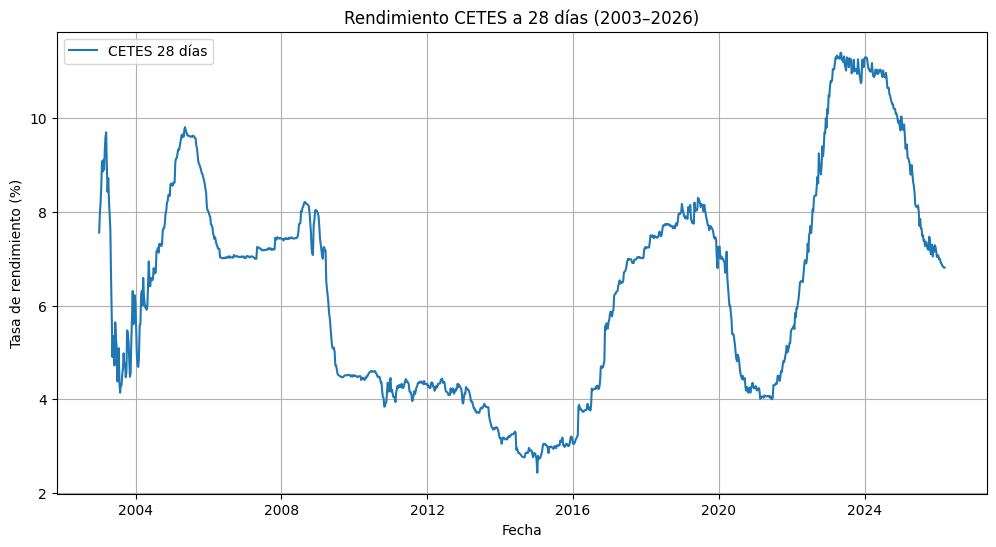

In [21]:
# Graficar rendimiento
plt.figure(figsize=(12,6))
plt.plot(df["Fecha"], df["Tasa"], label="CETES 28 días")

plt.title("Rendimiento CETES a 28 días (2003–2026)")
plt.xlabel("Fecha")
plt.ylabel("Tasa de rendimiento (%)")
plt.grid(True)
plt.legend()

plt.show()

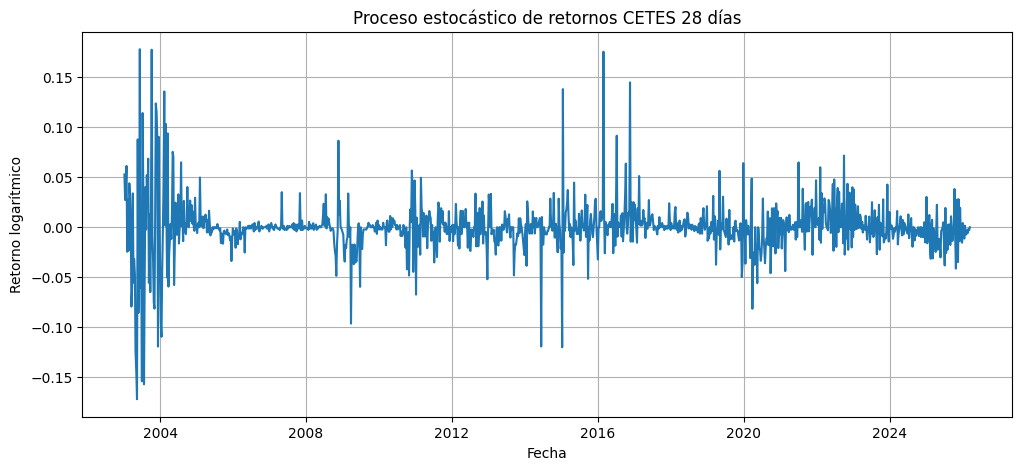

In [22]:
import numpy as np

# calcular retornos logarítmicos
df["retorno"] = np.log(df["Tasa"] / df["Tasa"].shift(1))

# gráfica del proceso estocástico
plt.figure(figsize=(12,5))
plt.plot(df["Fecha"], df["retorno"])
plt.title("Proceso estocástico de retornos CETES 28 días")
plt.xlabel("Fecha")
plt.ylabel("Retorno logarítmico")
plt.grid(True)

plt.show()

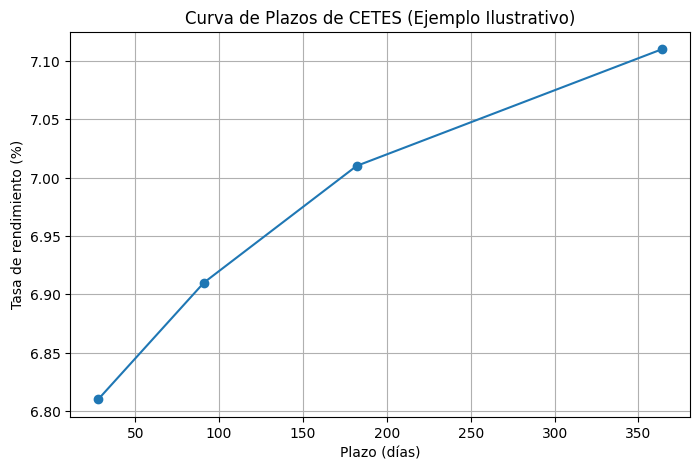

In [25]:
# Graficar curva de plazos
# Definir plazos y tasas para fines de demostración,
# ya que los datos reales para diferentes vencimientos no están disponibles en df.
# Usando la última tasa disponible a 28 días como base.
plazos = [28, 91, 182, 364] # Plazos de ejemplo en días
latest_28_day_rate = df["Tasa"].iloc[-1]
tasas = [latest_28_day_rate, latest_28_day_rate + 0.1, latest_28_day_rate + 0.2, latest_28_day_rate + 0.3] # Tasas de ejemplo (ligeramente ascendentes)

plt.figure(figsize=(8,5))
plt.plot(plazos, tasas, marker='o')

plt.title("Curva de Plazos de CETES")
plt.xlabel("Plazo (días)")
plt.ylabel("Tasa de rendimiento (%)")
plt.grid(True)

plt.show()

Curva ascendente: plazos largos pagan más.

##2-Proceso de Markov

Suponga que va a medir un proceso estocástico de Markov con estado
inicial $x_0=0$ que tiene probabilidad de aumento de una unidad de $\frac{1}{2}$ y probabilidad de disminuir en $\frac{1}{2}$



Calcule los primeros 10 pasos de la caminata aleatoria:

$x_1(ω), x_2(ω), x_3(ω), ..., x_{10}(ω)$.

Valores de la caminata:
x0 = 0
x1 = -1
x2 = -2
x3 = -1
x4 = 0
x5 = 1
x6 = 0
x7 = 1
x8 = 2
x9 = 1
x10 = 0


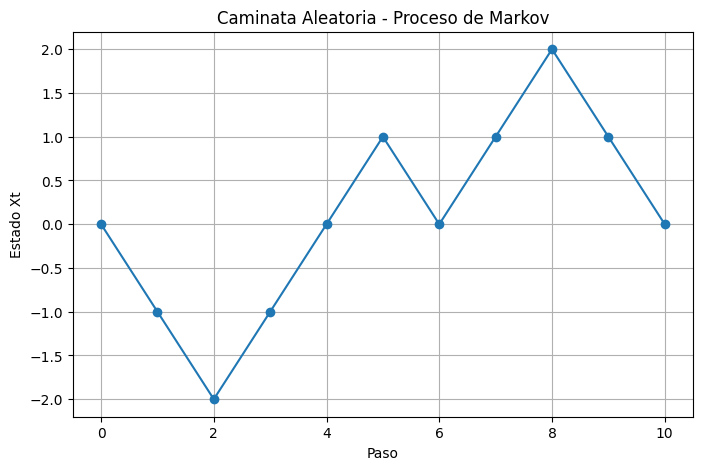

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del proceso
pasos = 10
X0 = 0

# Generar aumentos o disminuciones con probabilidad 1/2
movimientos = np.random.choice([-1, 1], size=pasos)

# Calcular la caminata aleatoria
X = [X0]

for m in movimientos:
    X.append(X[-1] + m)

# Pasos del proceso
t = list(range(0, pasos + 1))

# Mostrar resultados
print("Valores de la caminata:")
for i in range(len(X)):
    print(f"x{i} =", X[i])

# Graficar evolución del proceso de Markov
plt.figure(figsize=(8,5))
plt.plot(t, X, marker='o')

plt.title("Caminata Aleatoria - Proceso de Markov")
plt.xlabel("Paso")
plt.ylabel("Estado Xt")
plt.grid(True)

plt.show()